# EDA

In [25]:
# !pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
from funcs import custom_plot, custom_subplot
import numpy as np


In [26]:
# Using cp1252 encoding
df = pd.read_csv("data.csv")
pd.set_option('display.max_columns', None)

display(df.head())



,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order_Date,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,Shipping_Date,Shipping Mode,Post_Order_Action,Transportation_Cost,Lead_Time,Supplier_ID
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.0,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,NaN,23.641850,6,sup001
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.0,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,NaN,18.305349,10,sup004
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,95125.0,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,NaN,21.521161,8,sup004
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,90027.0,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,NaN,21.390399,6,sup002
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.0,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,NaN,26.171795,4,sup001


In [27]:
display(df.describe())

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Customer Id,Customer Zipcode,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Price,Product Status,Transportation_Cost,Lead_Time
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,180519.000000,180519.0,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,6691.379495,35921.126914,29.719955,-84.915675,6691.379495,36221.894903,692.509764,20.664741,0.101668,90260.000000,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,141.232550,0.0,13.734331,6.969510
std,1.623722,1.374449,104.433526,120.043670,0.497664,4162.918106,37542.461122,9.813646,21.433241,4162.918106,21045.379569,336.446807,21.800901,0.070415,52111.490959,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,139.732492,0.0,9.524049,3.290708
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,1.000000,603.000000,-33.937553,-158.025986,1.000000,1.000000,19.000000,0.000000,0.000000,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,9.990000,0.0,0.435127,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,3258.500000,725.000000,18.265432,-98.446312,3258.500000,18057.000000,403.000000,5.400000,0.040000,45130.500000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,50.000000,0.0,7.340420,4.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,6457.000000,19380.000000,33.144863,-76.847908,6457.000000,36140.000000,627.000000,14.000000,0.100000,90260.000000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,59.990002,0.0,11.657176,6.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,9779.000000,78207.000000,39.279617,-66.370583,9779.000000,54144.000000,1004.000000,29.990000,0.160000,135389.500000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,199.990005,0.0,18.285922,10.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,20757.000000,99205.000000,48.781933,115.263077,20757.000000,77204.000000,1363.000000,500.000000,0.250000,180519.000000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,1999.989990,0.0,180.347028,12.000000


In [28]:
null_counts = df.isnull().sum()
print(null_counts)



Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Customer Zipcode                      3
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0
Order City                            0
Order Country                         0
Order Customer Id                     0
Order_Date                            0
Order Id                              0
Order Item Cardprod Id                0
Order Item Discount                   0


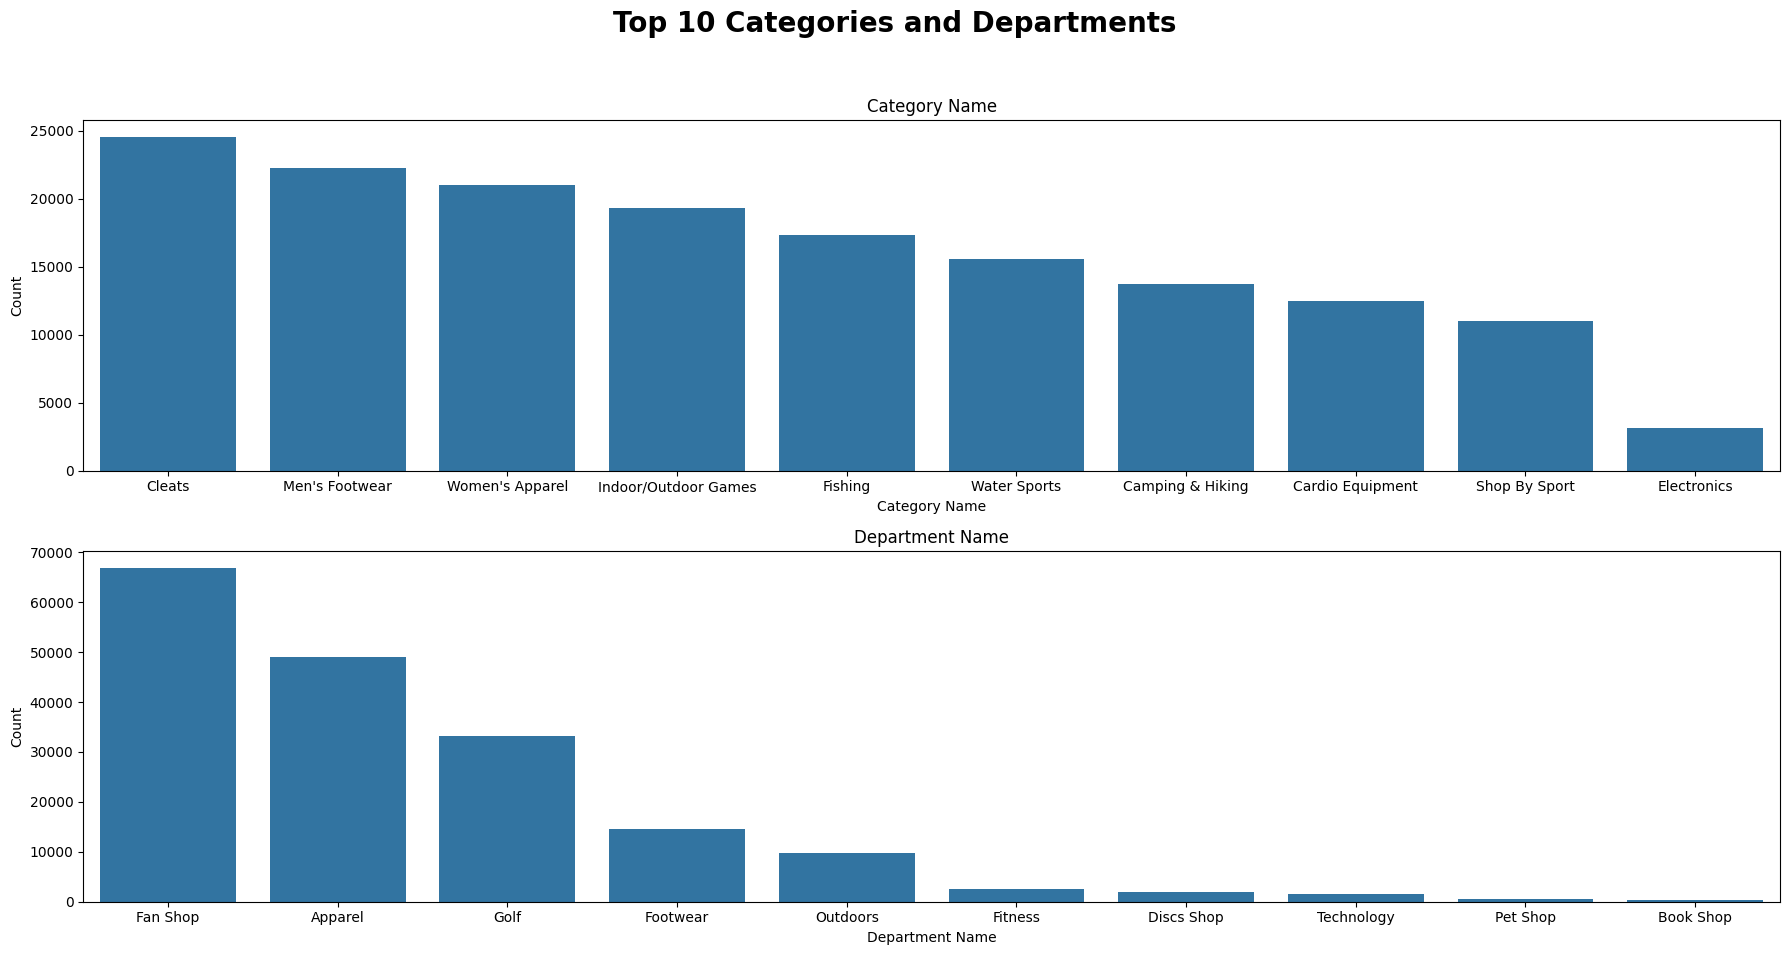

In [29]:
# Define the list of categorical columns
categorical_columns = ['Category Name', 'Department Name']

# Set up the figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
fig.suptitle('Top 10 Categories and Departments', fontsize=20, fontweight=700)

# Plot each categorical column in a subplot
for ax, col in zip(axes.flatten(), categorical_columns):
    # Calculate the counts and keep only the top 10 categories
    counts = df[col].value_counts().nlargest(10)
    # Plot the count plot with the top 10 categories
    sns.countplot(data=df[df[col].isin(counts.index)], x=col, ax=ax, order=counts.index)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


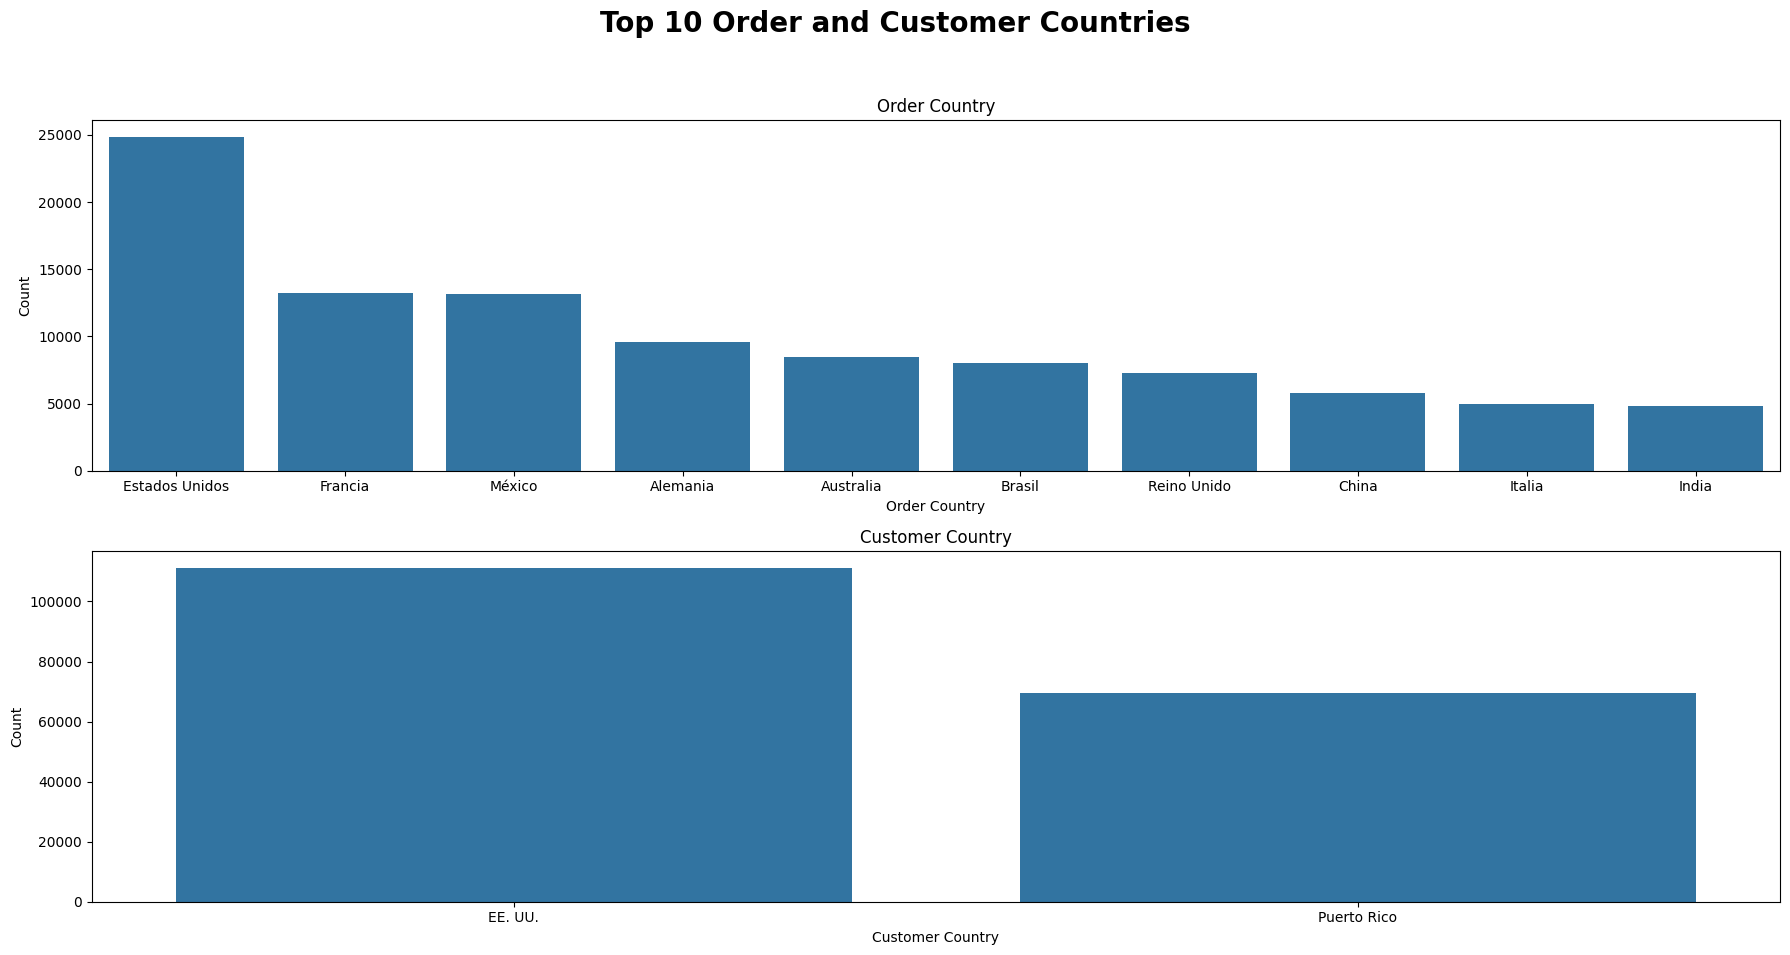

In [30]:
# Define the list of country columns
country_columns = ['Order Country', 'Customer Country']

# Set up the figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
fig.suptitle('Top 10 Order and Customer Countries', fontsize=20, fontweight=700)

# Plot each country column in a subplot
for ax, col in zip(axes.flatten(), country_columns):
    # Calculate the counts and keep only the top 10 countries
    counts = df[col].value_counts().nlargest(10)
    # Plot the count plot with the top 10 countries
    sns.countplot(data=df[df[col].isin(counts.index)], x=col, ax=ax, order=counts.index)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


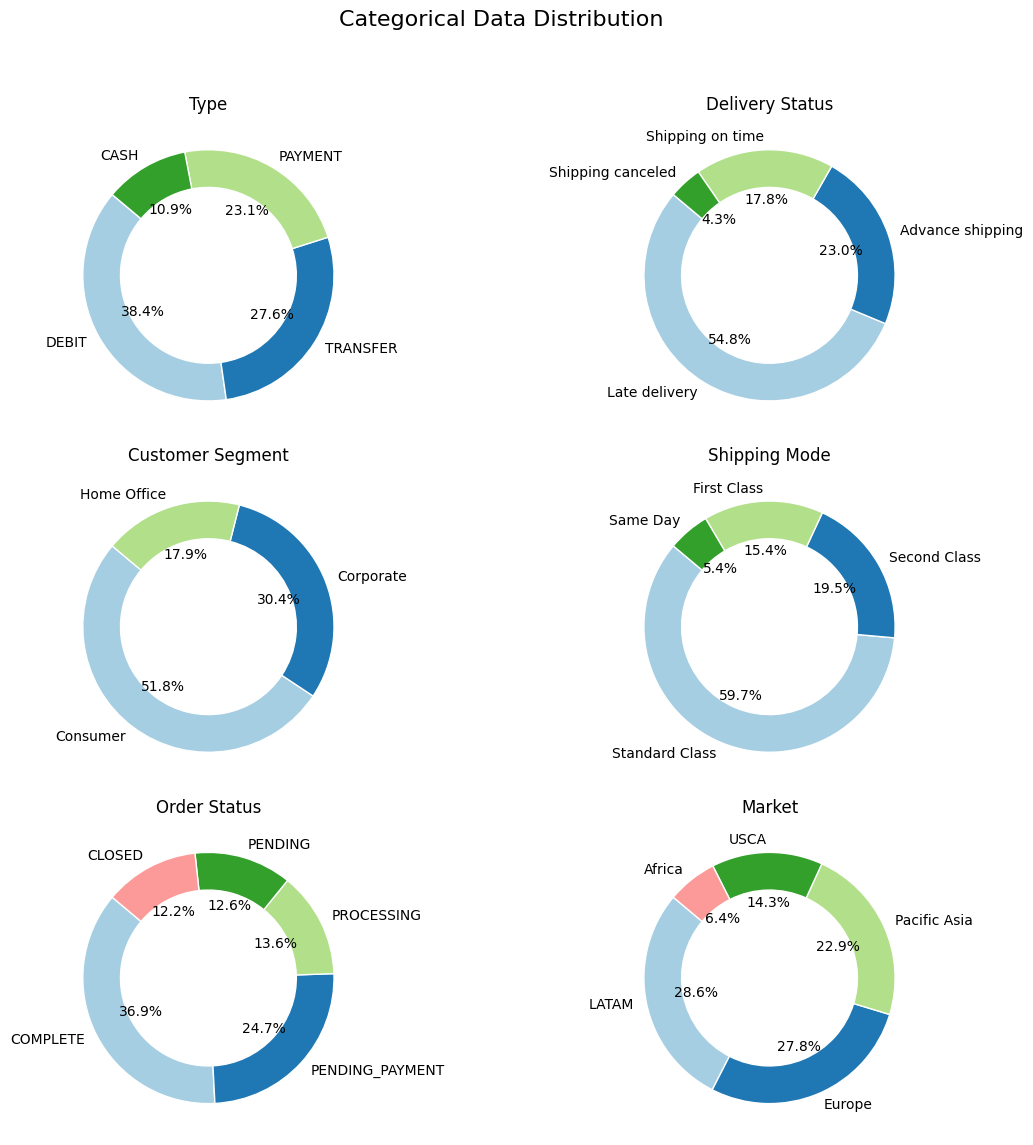

In [31]:
# Define the list of categorical columns
categorical_columns = ['Type', 'Delivery Status', 'Customer Segment', 'Shipping Mode','Order Status','Market']

# Set up the figure and subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
fig.suptitle('Categorical Data Distribution', fontsize=16)

# Plot each categorical column in a subplot
for ax, col in zip(axes.flatten(), categorical_columns):
    # Calculate the counts and keep only the top 5 categories
    counts = df[col].value_counts().nlargest(5)
    
    # Plot the pie chart with percentages and separation lines
    wedges, texts, autotexts = ax.pie(
        counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Paired.colors,
        wedgeprops=dict(width=0.3, edgecolor='w')
    )
    ax.set_title(col)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

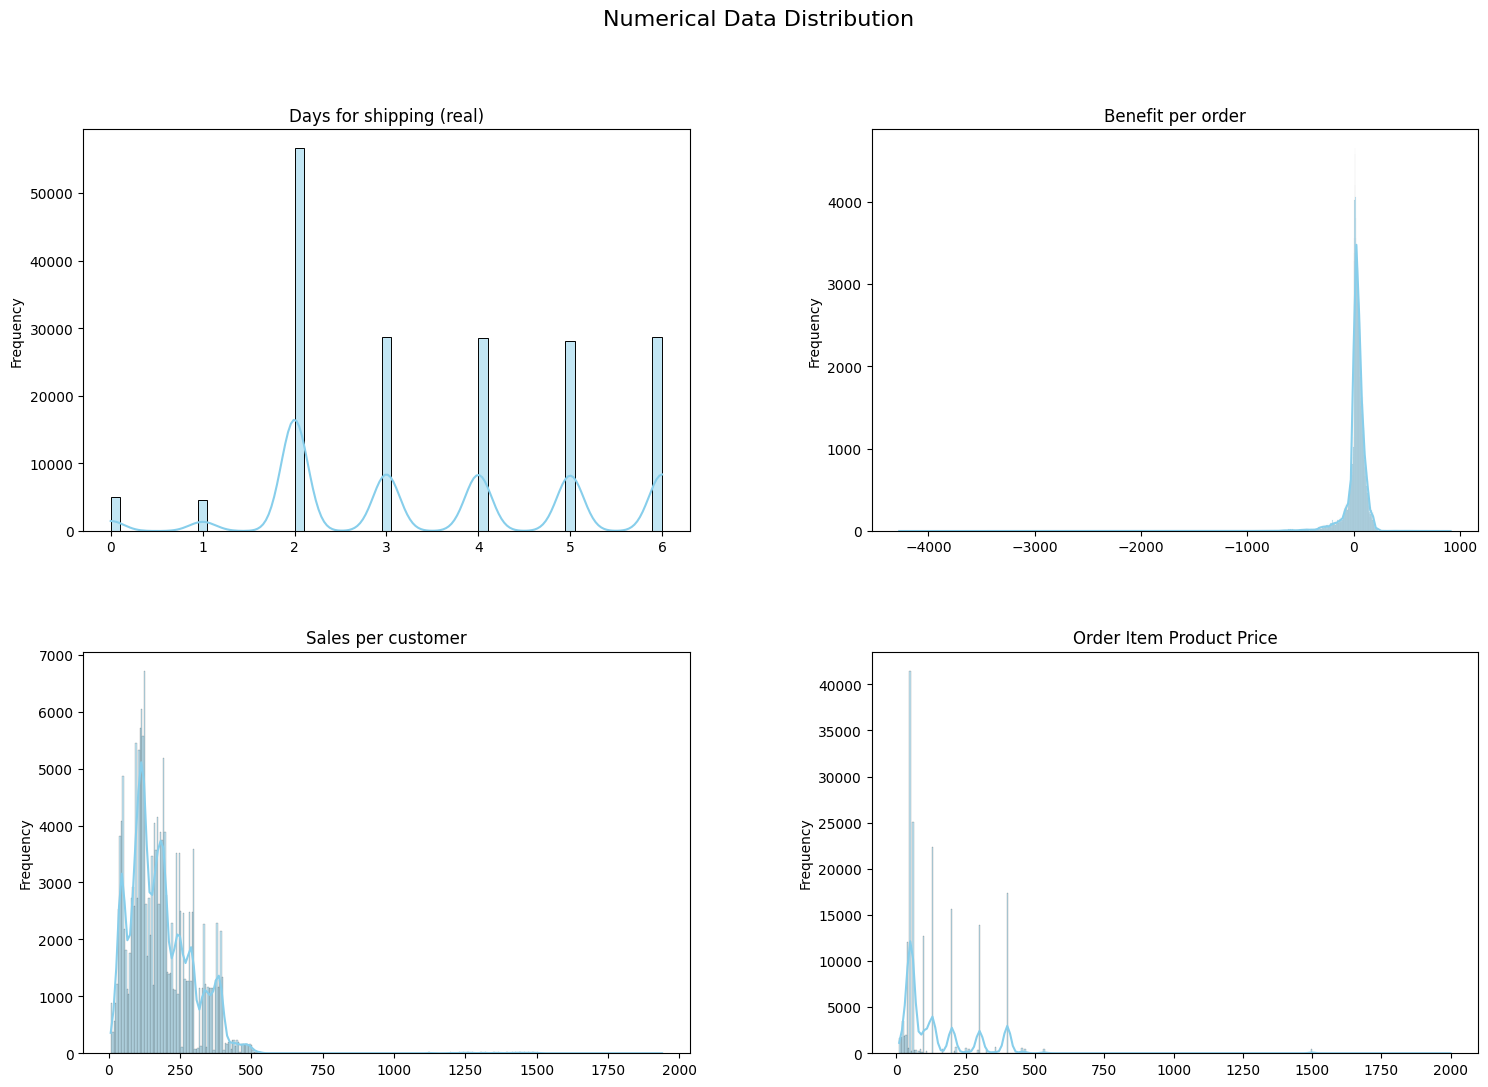

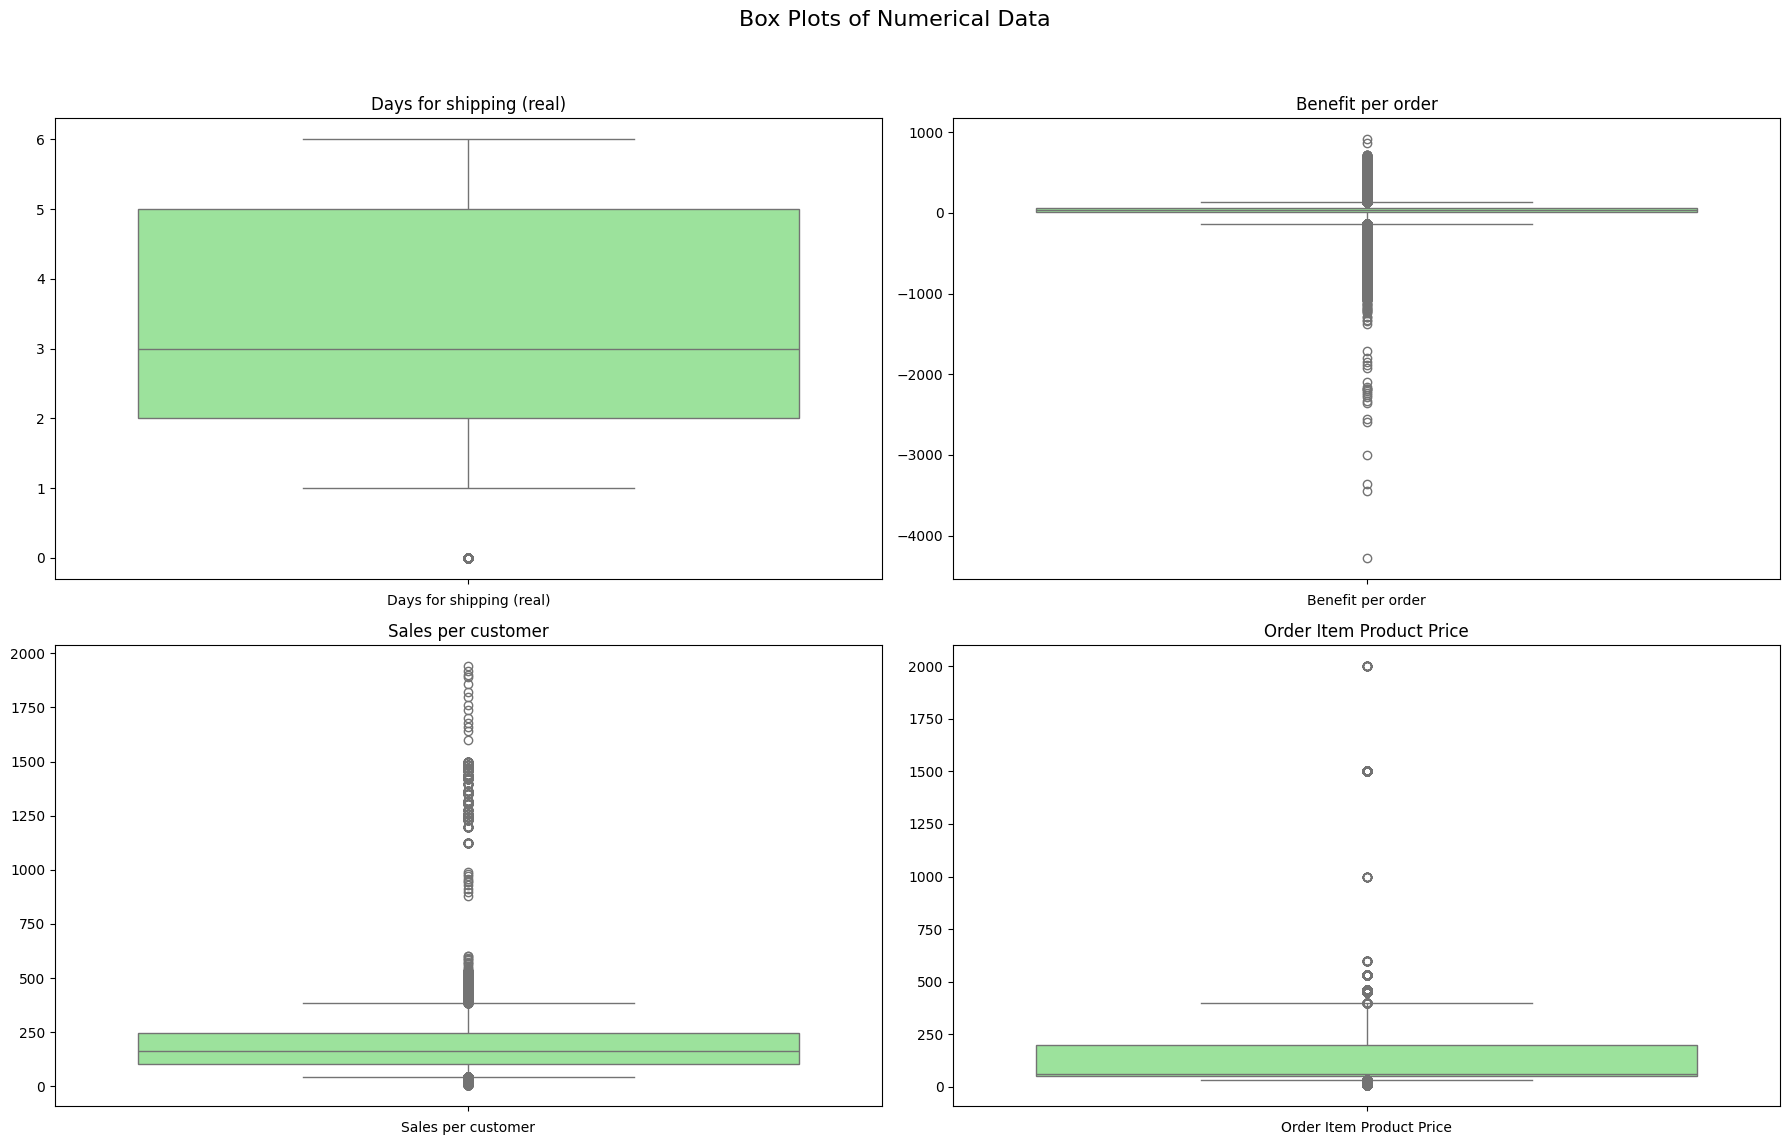

In [32]:
# Define the list of numerical columns
numerical_columns = [
    'Days for shipping (real)', 
    'Benefit per order', 
    'Sales per customer', 
    'Order Item Product Price'
]
# Set up the figure with GridSpec
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], hspace=0.3, wspace=0.3)
fig.suptitle('Numerical Data Distribution', fontsize=16)

# Plot histograms and density plots
for ax, col in zip(gs, numerical_columns):
    # Create a subplot in the GridSpec layout
    ax = plt.subplot(ax)
    
    # Plot histogram and density plot
    sns.histplot(df[col], kde=True, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

# Adjust layout
plt.show()

# Set up the figure for box plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.suptitle('Box Plots of Numerical Data', fontsize=16)

# Plot box plots
for ax, col in zip(axes.flatten(), numerical_columns):
    sns.boxplot(data=df, y=col, ax=ax, color='lightgreen', whis=[5, 95])
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel(col)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [33]:
import pandas as pd
import plotly.express as px


country_count = df['Order Country'].value_counts()
country_count_df = pd.DataFrame(country_count).reset_index()
display(country_count)
country_count.columns = ['Country', 'Count']




Order Country
Estados Unidos       24840
Francia              13222
México               13172
Alemania              9564
Australia             8497
                     ...  
Guinea Ecuatorial        2
Kuwait                   2
Sáhara Occidental        2
Burundi                  1
Serbia                   1
Name: count, Length: 164, dtype: int64

In [34]:
country_translation = {
    'Estados Unidos': 'United States of America', 'Francia': 'France', 'México': 'Mexico', 'Alemania': 'Germany', 'Australia': 'Australia',
    'Brasil': 'Brazil', 'Reino Unido': 'United Kingdom', 'China': 'China', 'Italia': 'Italy', 'India': 'India',
    'Indonesia': 'Indonesia', 'España': 'Spain', 'El Salvador': 'El Salvador', 'República Dominicana': 'Dominican Republic',
    'Honduras': 'Honduras', 'Cuba': 'Cuba', 'Turquía': 'Turkey', 'Nicaragua': 'Nicaragua', 'Guatemala': 'Guatemala',
    'Nigeria': 'Nigeria', 'Filipinas': 'Philippines', 'Panamá': 'Panama', 'Países Bajos': 'Netherlands', 'Argentina': 'Argentina',
    'Colombia': 'Colombia', 'Nueva Zelanda': 'New Zealand', 'Irán': 'Iran', 'Austria': 'Austria', 'Egipto': 'Egypt',
    'Marruecos': 'Morocco', 'SudAfrica': 'South Africa', 'Rusia': 'Russia', 'República Democrática del Congo': 'Democratic Republic of the Congo',
    'Venezuela': 'Venezuela', 'Irak': 'Iraq', 'Ucrania': 'Ukraine', 'Canada': 'Canada', 'Suecia': 'Sweden',
    'Tailandia': 'Thailand', 'Arabia Saudí': 'Saudi Arabia', 'Perú': 'Peru', 'Pakistán': 'Pakistan', 'Japón': 'Japan',
    'Vietnam': 'Vietnam', 'Chile': 'Chile', 'Bélgica': 'Belgium', 'Polonia': 'Poland', 'Corea del Sur': 'South Korea',
    'Malasia': 'Malaysia', 'Haití': 'Haiti', 'Argelia': 'Algeria', 'Irlanda': 'Ireland', 'Bangladés': 'Bangladesh',
    'Rumania': 'Romania', 'Singapur': 'Singapore', 'Myanmar (Birmania)': 'Myanmar (Burma)', 'Tanzania': 'Tanzania',
    'Portugal': 'Portugal', 'Noruega': 'Norway', 'Suiza': 'Switzerland', 'Angola': 'Angola', 'Ecuador': 'Ecuador',
    'Finlandia': 'Finland', 'Dinamarca': 'Denmark', 'Camerún': 'Cameroon', 'Kazajistán': 'Kazakhstan', 'Zambia': 'Zambia',
    'Israel': 'Israel', 'Ghana': 'Ghana', 'Senegal': 'Senegal', 'Costa de Marfil': 'Ivory Coast', 'Sudán': 'Sudan',
    'Mozambique': 'Mozambique', 'Kenia': 'Kenya', 'Bolivia': 'Bolivia', 'Bielorrusia': 'Belarus', 'Zimbabue': 'Zimbabwe',
    'República Checa': 'Czech Republic', 'Hungría': 'Hungary', 'Jamaica': 'Jamaica', 'Bulgaria': 'Bulgaria', 'Afganistán': 'Afghanistan',
    'Camboya': 'Cambodia', 'Madagascar': 'Madagascar', 'Somalia': 'Somalia', 'Uruguay': 'Uruguay', 'Trinidad y Tobago': 'Trinidad and Tobago',
    'Lituania': 'Lithuania', 'Togo': 'Togo', 'Uzbekistán': 'Uzbekistan', 'Martinica': 'Martinique', 'Barbados': 'Barbados',
    'Níger': 'Niger', 'Jordania': 'Jordan', 'Libia': 'Libya', 'Mali': 'Mali', 'Kirguistán': 'Kyrgyzstan', 'Uganda': 'Uganda',
    'Georgia': 'Georgia', 'Croacia': 'Croatia', 'Ruanda': 'Rwanda', 'Benín': 'Benin', 'Nepal': 'Nepal', 'Mongolia': 'Mongolia',
    'Paraguay': 'Paraguay', 'Moldavia': 'Moldova', 'Hong Kong': 'Hong Kong', 'Yemen': 'Yemen', 'Azerbaiyán': 'Azerbaijan',
    'Siria': 'Syria', 'Papúa Nueva Guinea': 'Papua New Guinea', 'Turkmenistán': 'Turkmenistan', 'Guinea': 'Guinea',
    'Bosnia y Herzegovina': 'Bosnia and Herzegovina', 'Gabón': 'Gabon', 'Qatar': 'Qatar', 'Sierra Leona': 'Sierra Leone',
    'Albania': 'Albania', 'Costa Rica': 'Costa Rica', 'Guadalupe': 'Guadeloupe', 'Túnez': 'Tunisia', 'Liberia': 'Liberia',
    'Yibuti': 'Djibouti', 'Emiratos Árabes Unidos': 'United Arab Emirates', 'Taiwán': 'Taiwan', 'Estonia': 'Estonia',
    'Guinea-Bissau': 'Guinea-Bissau', 'Grecia': 'Greece', 'Etiopía': 'Ethiopia', 'República Centroafricana': 'Central African Republic',
    'Eslovaquia': 'Slovakia', 'Mauritania': 'Mauritania', 'Namibia': 'Namibia', 'Lesoto': 'Lesotho', 'Líbano': 'Lebanon',
    'Guyana': 'Guyana', 'Sri Lanka': 'Sri Lanka', 'República del Congo': 'Republic of the Congo', 'Belice': 'Belize',
    'Botsuana': 'Botswana', 'Chipre': 'Cyprus', 'Montenegro': 'Montenegro', 'Burkina Faso': 'Burkina Faso',
    'Luxemburgo': 'Luxembourg', 'Guayana Francesa': 'French Guiana', 'Surinam': 'Suriname', 'Omán': 'Oman',
    'Tayikistán': 'Tajikistan', 'Eslovenia': 'Slovenia', 'Macedonia': 'North Macedonia', 'Laos': 'Laos', 'Suazilandia': 'Eswatini',
    'República de Gambia': 'The Gambia', 'Sudán del Sur': 'South Sudan', 'Armenia': 'Armenia', 'Bután': 'Bhutan',
    'Baréin': 'Bahrain', 'Chad': 'Chad', 'Eritrea': 'Eritrea', 'Guinea Ecuatorial': 'Equatorial Guinea', 'Kuwait': 'Kuwait',
    'Sáhara Occidental': 'Western Sahara', 'Burundi': 'Burundi', 'Serbia': 'Serbia'
}
country_translation_df =pd.DataFrame(country_translation.items(), columns=['Order Country', 'English_Name'])
display(country_translation_df)

country_count_df = pd.merge(country_count_df, country_translation_df, on='Order Country')
country_count_df.to_csv("geo_location.csv")
display(country_count_df)

,Order Country,English_Name
0,Estados Unidos,United States of America
1,Francia,France
2,México,Mexico
3,Alemania,Germany
4,Australia,Australia
...,...,...
159,Guinea Ecuatorial,Equatorial Guinea
160,Kuwait,Kuwait
161,Sáhara Occidental,Western Sahara
162,Burundi,Burundi


,Order Country,count,English_Name
0,Estados Unidos,24840,United States of America
1,Francia,13222,France
2,México,13172,Mexico
3,Alemania,9564,Germany
4,Australia,8497,Australia
...,...,...,...
159,Guinea Ecuatorial,2,Equatorial Guinea
160,Kuwait,2,Kuwait
161,Sáhara Occidental,2,Western Sahara
162,Burundi,1,Burundi


In [35]:
import plotly.express as px


# Assuming the DataFrame is named `country_count_df` and has columns 'Order Country' and 'count'
fig = px.choropleth(
    country_count_df,
    locations="English_Name",
    locationmode="country names",
    color="count",
    hover_name="English_Name",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Order Country Count"
)

# Updating the layout to set the size
fig.update_layout(
    width=1500,
    height=800
)

fig.show()

In [36]:
import pandas as pd
import plotly.express as px

# Assuming your DataFrame is named 'df' and the column with country names is 'Customer Country'
df['Customer State'] = df['Customer State']

# Create a DataFrame with updated counts
Customer_State_count = pd.DataFrame(df['Customer State'].value_counts())
# display(Customer_State_count)
# Create the choropleth map
fig = px.choropleth(
    Customer_State_count,
    locations=Customer_State_count.index,
    locationmode="USA-states",
    color="count",
    hover_name=Customer_State_count.index,
    color_continuous_scale=px.colors.sequential.Plasma,
    title="USA Customer City Count"
)

# Set the map's center and zoom level to focus on USA and Puerto Rico
fig.update_geos(
    center=dict(lon=-95, lat=37),  # Adjust longitude and latitude as needed
    projection_scale=2.5,  # Increase or decrease for desired zoom level
)

# Update the layout to set the size
fig.update_layout(
    width=1500,
    height=800
)

# Show the plot
fig.show()


Order Country
Estados Unidos    13670
Francia            7341
México             7246
Alemania           5383
Australia          4613
Brasil             4331
Reino Unido        3903
China              3123
India              2684
Italia             2672
Name: count, dtype: int64

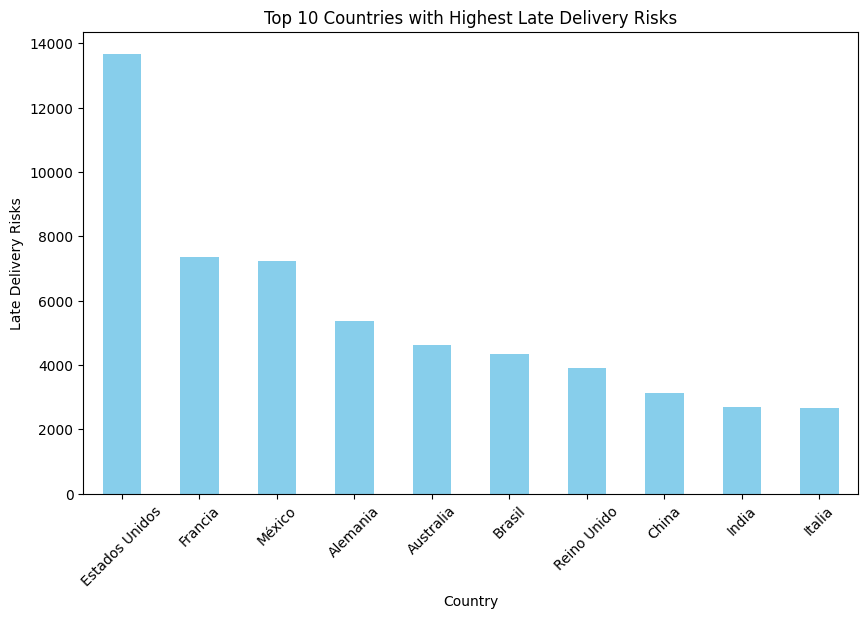

In [37]:

late_deliveries = df[df['Late_delivery_risk'] == 1]

late_delivery_counts = late_deliveries['Order Country'].value_counts()

top_10_countries = late_delivery_counts.head(10)
display(top_10_countries)
plt.figure(figsize=(10, 6))
top_10_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries with Highest Late Delivery Risks')
plt.xlabel('Country')
plt.ylabel('Late Delivery Risks')
plt.xticks(rotation=45)
plt.show()

Category Name
Cleats                  13496
Men's Footwear          12121
Women's Apparel         11476
Indoor/Outdoor Games    10565
Fishing                  9516
Water Sports             8517
Camping & Hiking         7487
Cardio Equipment         6805
Shop By Sport            6058
Electronics              1770
Name: count, dtype: int64

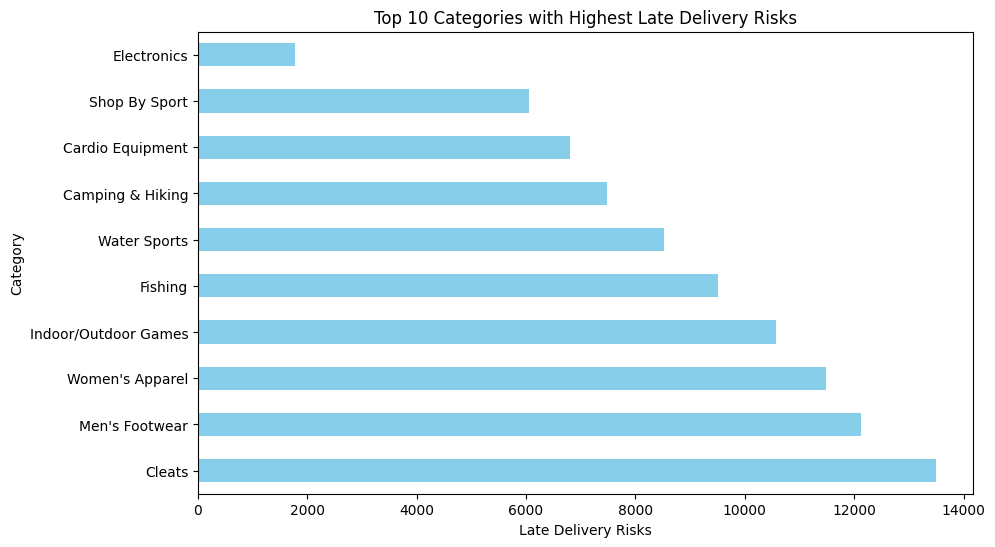

In [38]:
late_deliveries = df[df['Late_delivery_risk'] == 1]

late_delivery_counts = late_deliveries['Category Name'].value_counts()


top_10_categories = late_delivery_counts.head(10)
display(top_10_categories)


plt.figure(figsize=(10, 6))
top_10_categories.plot(kind='barh', color='skyblue') 
plt.title('Top 10 Categories with Highest Late Delivery Risks')
plt.ylabel('Category')
plt.xlabel('Late Delivery Risks')
plt.xticks(rotation=0) 
plt.show()

,Customer Id,Order Item Quantity,Late_delivery_risk
0,1,5,1.000000
1,2,19,0.300000
2,3,33,0.000000
3,4,34,0.785714
4,5,18,0.714286
...,...,...,...
20647,20753,1,1.000000
20648,20754,1,0.000000
20649,20755,1,0.000000
20650,20756,1,0.000000


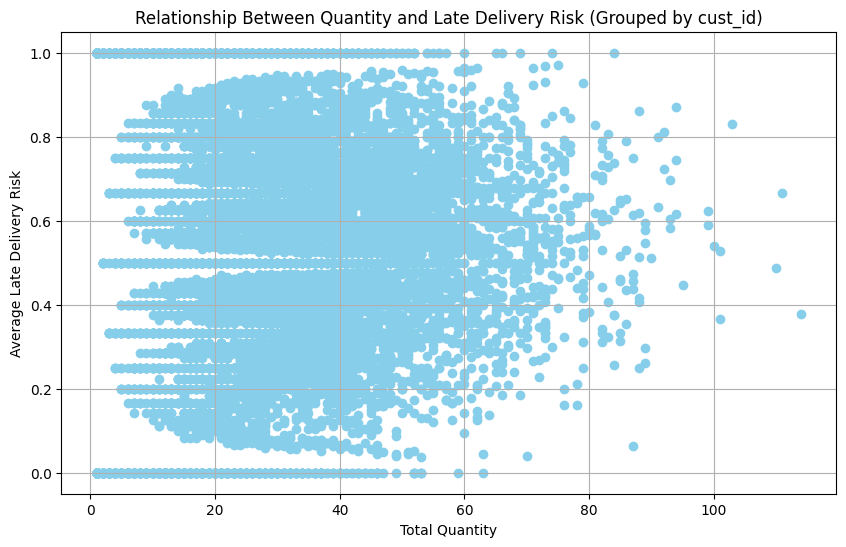

In [39]:
grouped_df = df.groupby('Customer Id').agg({
    'Order Item Quantity': 'sum', 
    'Late_delivery_risk': 'mean' 
}).reset_index()
display (grouped_df)


plt.figure(figsize=(10, 6))
plt.scatter(grouped_df['Order Item Quantity'], grouped_df['Late_delivery_risk'], color='skyblue')
plt.title('Relationship Between Quantity and Late Delivery Risk (Grouped by cust_id)')
plt.xlabel('Total Quantity')
plt.ylabel('Average Late Delivery Risk')
plt.grid(True)
plt.show()

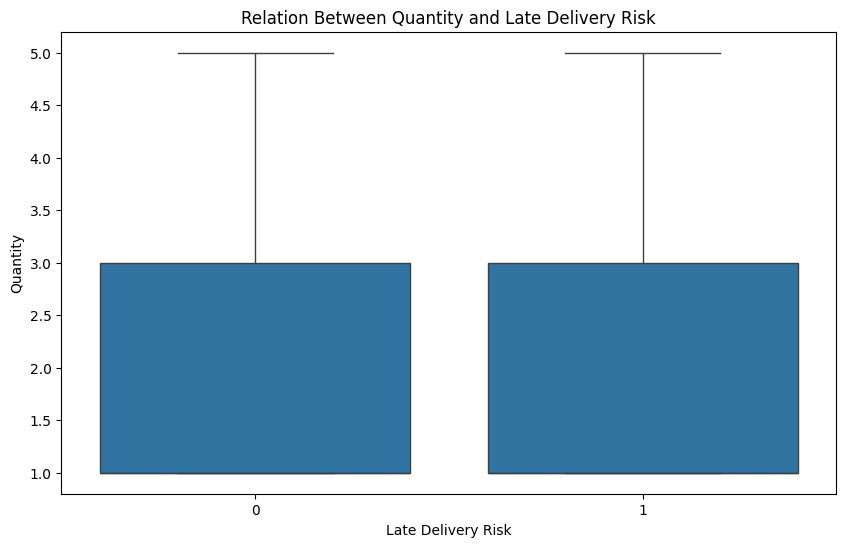

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Late_delivery_risk', y='Order Item Quantity', data=df)
plt.title('Relation Between Quantity and Late Delivery Risk')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Quantity')
plt.show()

In [42]:
# Step 1: Define the buckets
bins = [0, 2, 4, float('inf')]
labels = ['1-2', '3-4', '5 and above']

# Step 2: Create a new column with bucket categories
df['Quantity_Bucket'] = pd.cut(df['Order Item Quantity'], bins=bins, labels=labels, right=False)

# Step 3: Create a Delivery Status column based on Late_delivery_risk
df['Delivery_Status'] = df['Late_delivery_risk'].apply(lambda x: 'Late' if x  else 'On Time')

# Step 4: Group by the bucket and delivery status, then count occurrences
counts_df = df.groupby(['Quantity_Bucket', 'Delivery_Status']).size().unstack().fillna(0)

# Step 5: Plot the double bar graph
display(counts_df)

# Step 5: Calculate the percentage for each bucket
percentage_df = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

display(percentage_df)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11720\1843076722.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Delivery_Status,Late,On Time
Quantity_Bucket,,
1-2,54405,44729
3-4,22255,18410
5 and above,22317,18403


Delivery_Status,Late,On Time
Quantity_Bucket,,
1-2,54.880263,45.119737
3-4,54.727653,45.272347
5 and above,54.805992,45.194008


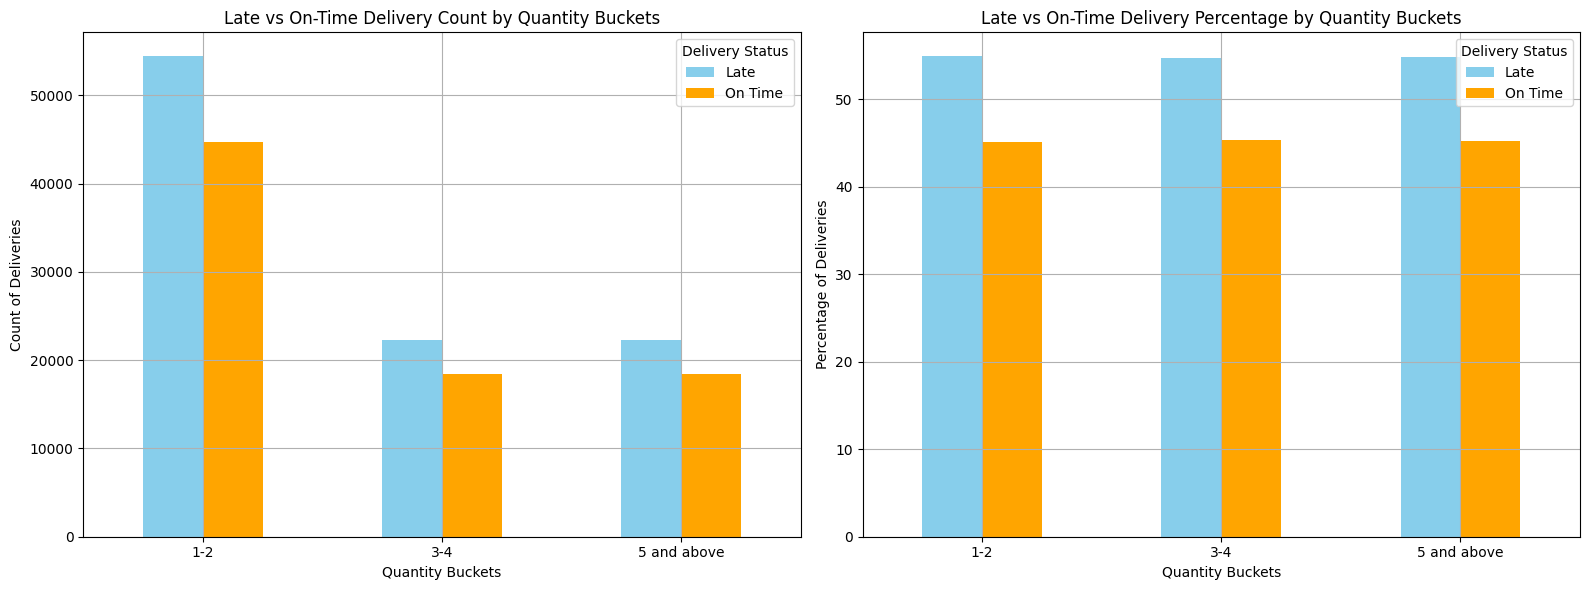

In [ ]:

# Step 6: Create the subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Actual Counts
counts_df.plot(kind='bar', stacked=False, color=['skyblue', 'orange'], ax=axes[0])
axes[0].set_title('Late vs On-Time Delivery Count by Quantity Buckets')
axes[0].set_xlabel('Quantity Buckets')
axes[0].set_ylabel('Count of Deliveries')
axes[0].legend(title='Delivery Status')
axes[0].grid(True)
axes[0].set_xticklabels(labels, rotation=0)

# Subplot 2: Percentages
percentage_df.plot(kind='bar', stacked=False, color=['skyblue', 'orange'], ax=axes[1])
axes[1].set_title('Late vs On-Time Delivery Percentage by Quantity Buckets')
axes[1].set_xlabel('Quantity Buckets')
axes[1].set_ylabel('Percentage of Deliveries')
axes[1].legend(title='Delivery Status')
axes[1].grid(True)
axes[1].set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()